# Business Understanding

## Project Domain

Domain: Automotive & Retail Analytics
Sub-Domain: Vehicle Pricing & Valuation Systems

Prediksi harga mobil (Car Price Prediction) merupakan bagian dari sistem penilaian kendaraan yang berbasis data, yang bertujuan untuk membantu perusahaan otomotif, platform jual-beli mobil, dan konsumen dalam menentukan harga mobil secara objektif. Dengan menggunakan data historis seperti usia kendaraan, kilometer tempuh, tenaga mesin, dan kapasitas mesin, sistem ini menerapkan algoritma Artificial Neural Network (ANN) untuk memberikan estimasi harga yang akurat dan konsisten. Pendekatan ini meningkatkan transparansi harga, mempercepat proses transaksi, serta meminimalkan risiko penilaian yang tidak tepat di pasar otomotif.

## Problem Statements

Masalah yang Dihadapi:
1. Ketidaktepatan dalam Penilaian Harga Mobil
Banyak individu maupun dealer mobil bekas menetapkan harga kendaraan secara subjektif, tanpa mempertimbangkan parameter teknis seperti kilometer tempuh, usia kendaraan, tenaga mesin, atau kapasitas mesin. Hal ini menyebabkan perbedaan harga yang tidak wajar di pasar.

2. Kurangnya Transparansi dalam Transaksi
Pembeli seringkali kesulitan menilai apakah harga yang ditawarkan wajar atau tidak. Penjual juga menghadapi tantangan dalam membenarkan harga yang mereka tetapkan tanpa dasar data yang jelas.

3. Ketergantungan pada Evaluasi Manual
Proses evaluasi harga yang masih dilakukan secara manual atau berdasarkan pengalaman memerlukan waktu, tenaga, dan rentan terhadap kesalahan manusia.

4. Variasi Nilai Aset yang Tidak Terdeteksi
Faktor-faktor penting seperti kondisi kendaraan, spesifikasi teknis, dan performa mesin sering tidak terkuantifikasi dengan baik, sehingga sulit untuk menentukan nilai pasar secara adil dan akurat.



## Goals

Membangun sistem berbasis Artificial Neural Network (ANN) yang mampu memprediksi harga jual mobil secara akurat berdasarkan parameter teknis seperti:

- Kilometer yang Telah Ditempuh (Kilometers Driven)

- Usia Kendaraan (Car Age)

- Kapasitas Mesin (Engine)

- Tenaga Mesin (Power)

Tujuan utama dari proyek ini adalah memberikan solusi prediktif berbasis data untuk:

- Membantu pembeli dan penjual kendaraan menentukan harga pasar yang wajar

- Mengurangi subjektivitas dalam proses penilaian harga

- Meningkatkan efisiensi dan transparansi dalam transaksi mobil bekas

- Mengintegrasikan model ke dalam aplikasi web/mobile untuk pemakaian real-time oleh dealer atau konsumen

## Solution Statements

- **Model Prediksi Harga Mobil Menggunakan Artificial Neural Network (ANN)**
Membangun model machine learning berbasis ANN yang dilatih dengan fitur numerik seperti usia kendaraan, jarak tempuh, kapasitas mesin, dan tenaga untuk memprediksi harga jual mobil dengan tingkat akurasi tinggi dan kesalahan minimum (low MAE/MSE).

- **Antarmuka Aplikasi Prediktif (Streamlit)**
Mengembangkan antarmuka pengguna berbasis web menggunakan Streamlit, yang memungkinkan pengguna seperti dealer, penjual mobil bekas, atau konsumen akhir untuk memasukkan spesifikasi mobil dan langsung mendapatkan estimasi harga jual secara instan dan user-friendly.

- **Optimasi Model untuk Perangkat Ringan dengan TensorFlow Lite**
Mengonversi model ANN ke format TFLite untuk memfasilitasi integrasi ke dalam aplikasi seluler atau perangkat embedded, sehingga dapat digunakan oleh pengguna lapangan tanpa memerlukan infrastruktur komputasi yang besar.

# Data Understanding

## Import data dari kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"znlindan","key":"caa1bc43b3a25035556a8adcf91c237e"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [4]:
!kaggle datasets download -d yashpaloswal/ann-car-sales-price-prediction

Dataset URL: https://www.kaggle.com/datasets/yashpaloswal/ann-car-sales-price-prediction
License(s): DbCL-1.0


In [5]:
!mkdir ann-car-sales-price-prediction
!unzip ann-car-sales-price-prediction.zip -d ann-car-sales-price-prediction
!ls ann-car-sales-price-prediction

Archive:  ann-car-sales-price-prediction.zip
  inflating: ann-car-sales-price-prediction/car_purchasing.csv  
car_purchasing.csv


## Import Library yang dibutuhkan

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import r2_score

## Exploratory Data Analysis

In [18]:
df = pd.read_csv('/content/ann-car-sales-price-prediction.zip', encoding='latin-1')

In [19]:
df.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB


# Data Preparation

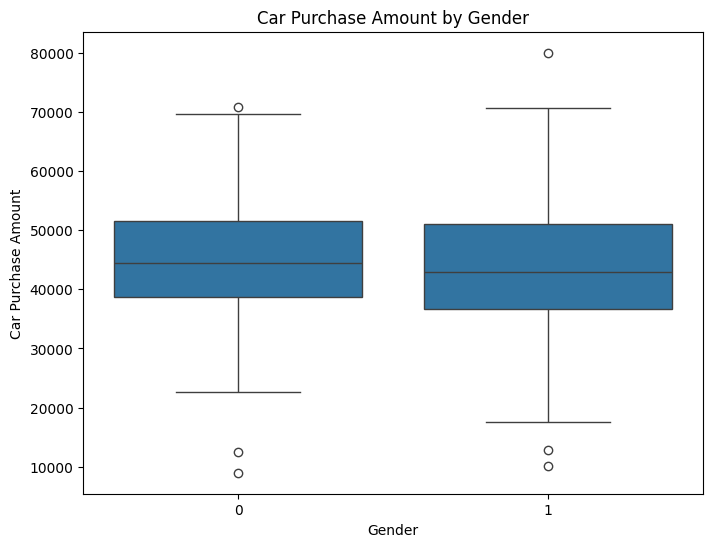

In [21]:
#Boxplot of Purchase Amount by Gender
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='car purchase amount', data=df)
plt.title('Car Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Car Purchase Amount')
plt.show()

In [22]:
df.drop(columns=['customer name', 'customer e-mail', 'country', 'gender'], inplace=True)

In [23]:
df.head()

,age,annual Salary,credit card debt,net worth,car purchase amount
0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [24]:
X = df.drop('car purchase amount', axis=1)
y = df['car purchase amount']

In [25]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(400, 4)
(400, 1)
(100, 4)
(100, 1)


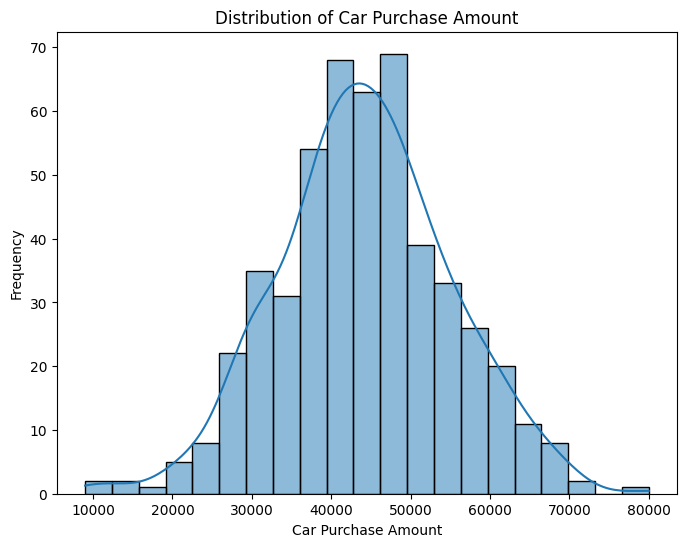

In [27]:
# Distribution of Car Purchase Amount
plt.figure(figsize=(8, 6))
sns.histplot(df['car purchase amount'], kde=True)
plt.title('Distribution of Car Purchase Amount')
plt.xlabel('Car Purchase Amount')
plt.ylabel('Frequency')
plt.show()

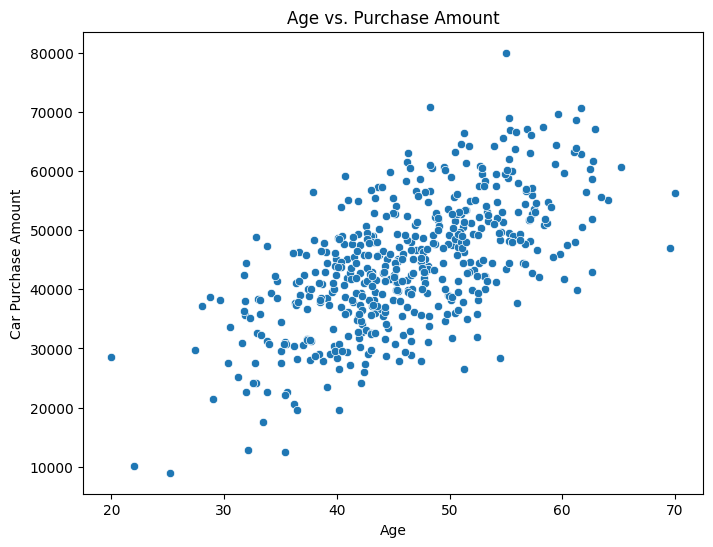

In [31]:
#Scatter plot of Age vs Purchase Amount
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='car purchase amount', data=df)
plt.title('Age vs. Purchase Amount')
plt.xlabel('Age')
plt.ylabel('Car Purchase Amount')
plt.show()

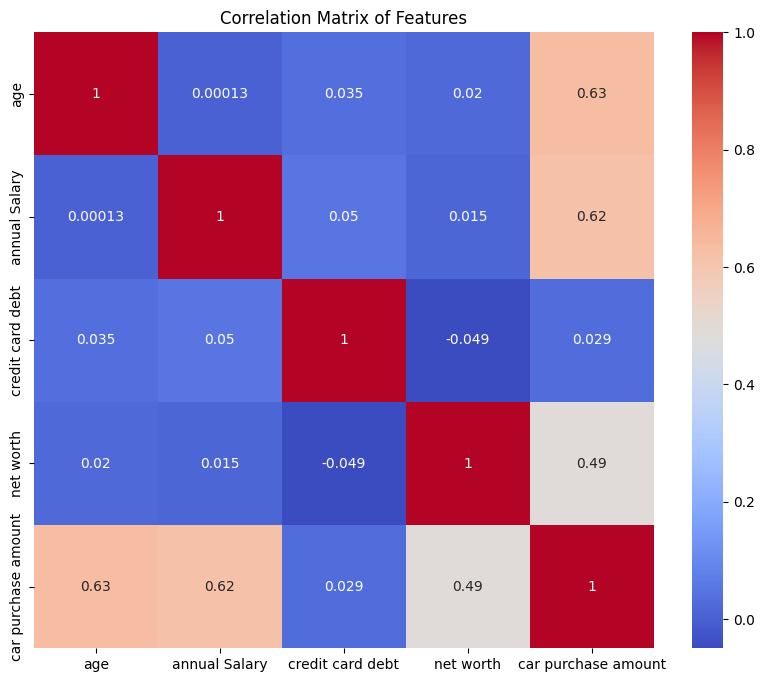

In [29]:
#Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

# Modeling

In [32]:
model = Sequential()
model.add(Dense(10, activation='relu', input_dim=4))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

In [62]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171 (684.00 B)

 Trainable params: 171 (684.00 B)

 Non-trainable params: 0 (0.00 B)

In [63]:
history = model.fit(X_train, y_train, epochs=1000, validation_split=0.2)

Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.0058 - loss: 7.6908e-05 - val_accuracy: 0.0125 - val_loss: 6.2462e-05
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0043 - loss: 3.0422e-05 - val_accuracy: 0.0125 - val_loss: 1.3413e-05
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0034 - loss: 1.1327e-05 - val_accuracy: 0.0125 - val_loss: 6.9480e-08
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0043 - loss: 2.2517e-06 - val_accuracy: 0.0125 - val_loss: 1.1506e-06
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0021 - loss: 1.0928e-06 - val_accuracy: 0.0125 - val_loss: 8.3730e-07
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0012 - loss: 4.8861e-07 - val_accuracy: 0.0125 - val_loss: 3.4115e-07
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0027 - loss: 1.7576e-07 - val_accuracy: 0.0125 - val_loss: 7.1603e-08
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/

# Evaluation

In [64]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [65]:
# Hitung akurasi menggunakan R-squared
r2 = r2_score(y_test, y_pred)
print(f'Akurasi (R-squared): {r2 * 100:.2f}%')


Akurasi (R-squared): 99.99%


In [66]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

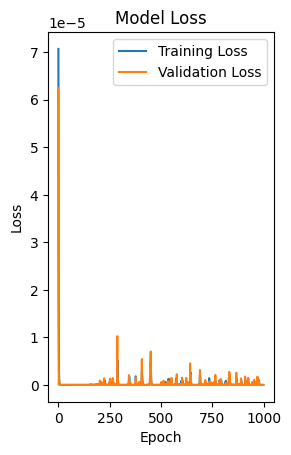

In [67]:
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

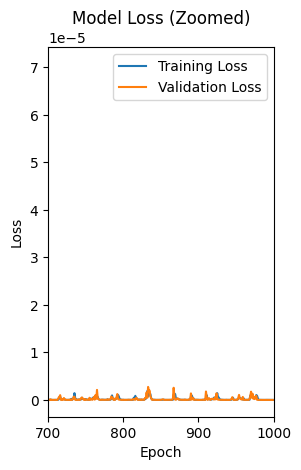

In [68]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss (Zoomed)')
plt.xlim([700,1000]) # example values
plt.legend()

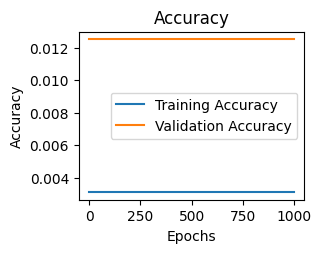

In [69]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

# Deployment

## Model Simulation

In [38]:
sample_input = np.array([[57.313749, 59729.15130, 5358.712177, 560304.0671]])
sample_input_scaled = scaler_X.transform(sample_input)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [39]:
predicted_price_scaled = model.predict(sample_input_scaled)
predicted_price = scaler_y.inverse_transform(predicted_price_scaled)
print(f"Predicted Price: {predicted_price[0][0]:.5f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Price: 55928.87109


## Save Model

In [40]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('ann-car-sales-price-prediction.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp1eax0684'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134315128290960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134315128291152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134315128290768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134315128288848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134315012949008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134315012949776: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [41]:
import joblib

# Simpan scaler X dan y
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

['scaler_y.pkl']